   # Fuel Consumption

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv("ship_fuel_efficiency.csv")
df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


In [14]:
df.shape

(1440, 10)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ship_id             1440 non-null   object 
 1   ship_type           1440 non-null   object 
 2   route_id            1440 non-null   object 
 3   month               1440 non-null   object 
 4   distance            1440 non-null   float64
 5   fuel_type           1440 non-null   object 
 6   fuel_consumption    1440 non-null   float64
 7   CO2_emissions       1440 non-null   float64
 8   weather_conditions  1440 non-null   object 
 9   engine_efficiency   1440 non-null   float64
dtypes: float64(4), object(6)
memory usage: 112.6+ KB


In [20]:
df.isnull().sum()

ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64

In [22]:
df.duplicated().sum()

0

In [26]:
numeric_columns=['distance','CO2_emissions','engine_efficiency']
categoric_columns=['ship_type','route_id','month','fuel_type','weather_conditions']
numeric_columns,categoric_columns

(['distance', 'CO2_emissions', 'engine_efficiency'],
 ['ship_type', 'route_id', 'month', 'fuel_type', 'weather_conditions'])

# Data Visualization

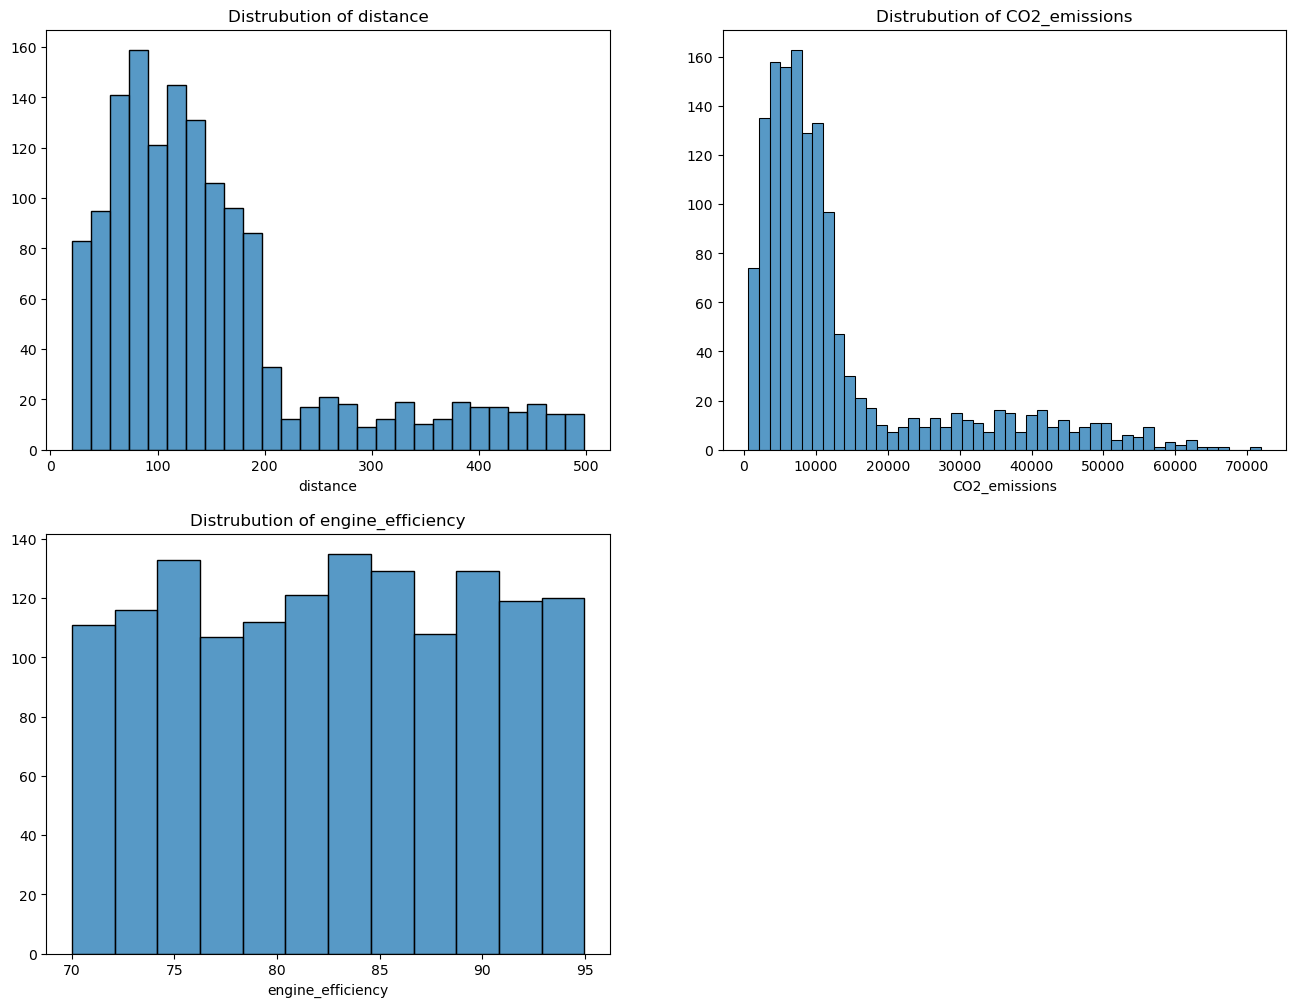

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(16,12))
for i,col in enumerate(numeric_columns):
    i+=1
    plt.subplot(2,2,i)
    sns.histplot(x=df[col])
    plt.title(f"Distrubution of {col}")
    plt.xlabel(col)
    plt.ylabel(f"")
plt.show()
plt.tight_layout()

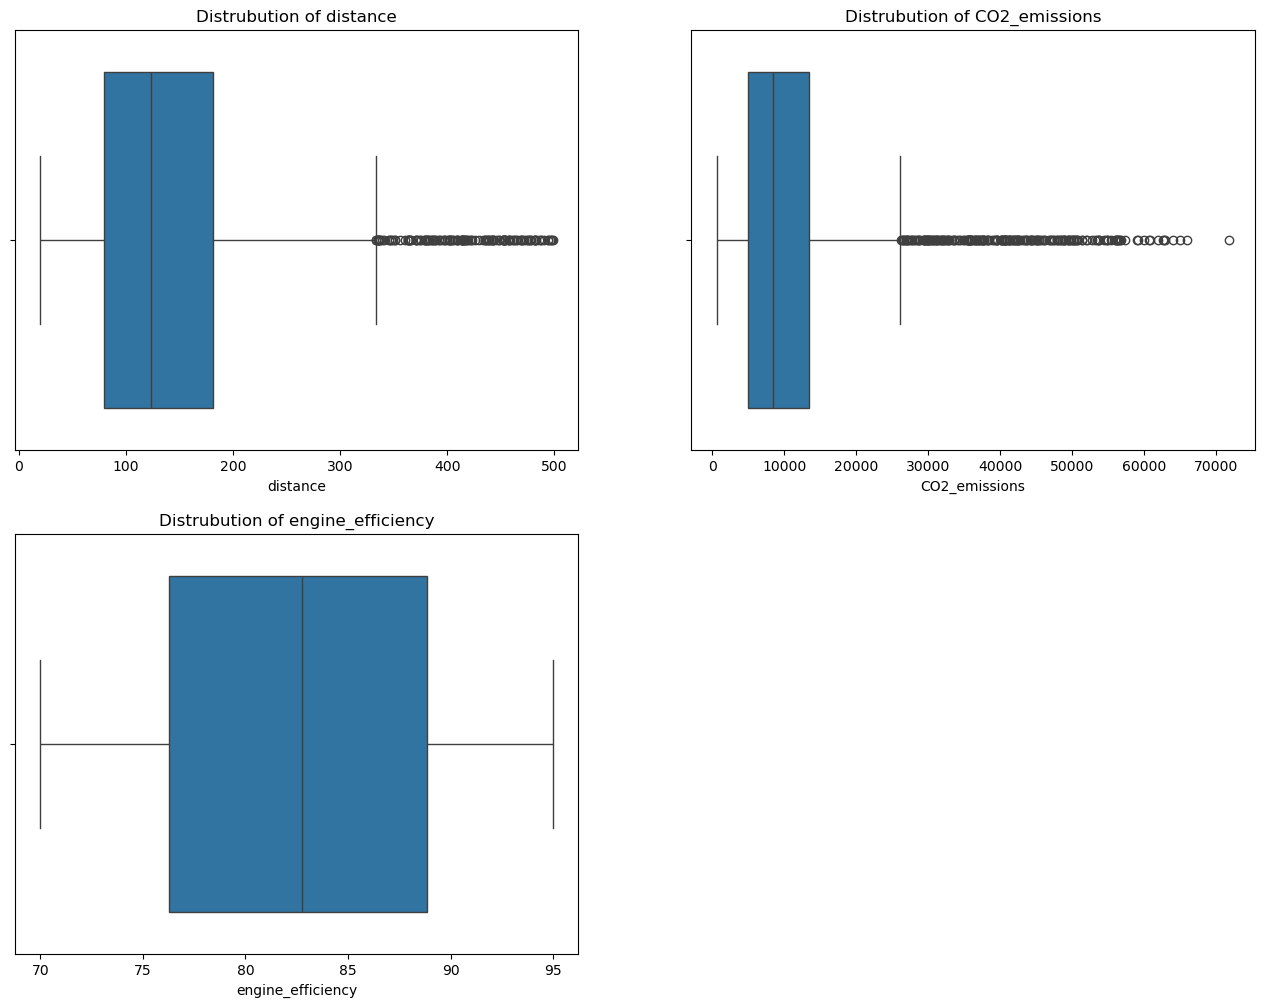

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure(figsize=(16,12))
for i,col in enumerate(numeric_columns):
    i+=1
    plt.subplot(2,2,i)
    sns.boxplot(x=df[col])
    plt.title(f"Distrubution of {col}")
    plt.xlabel(col)
    plt.ylabel(f"")
plt.show()
plt.tight_layout()

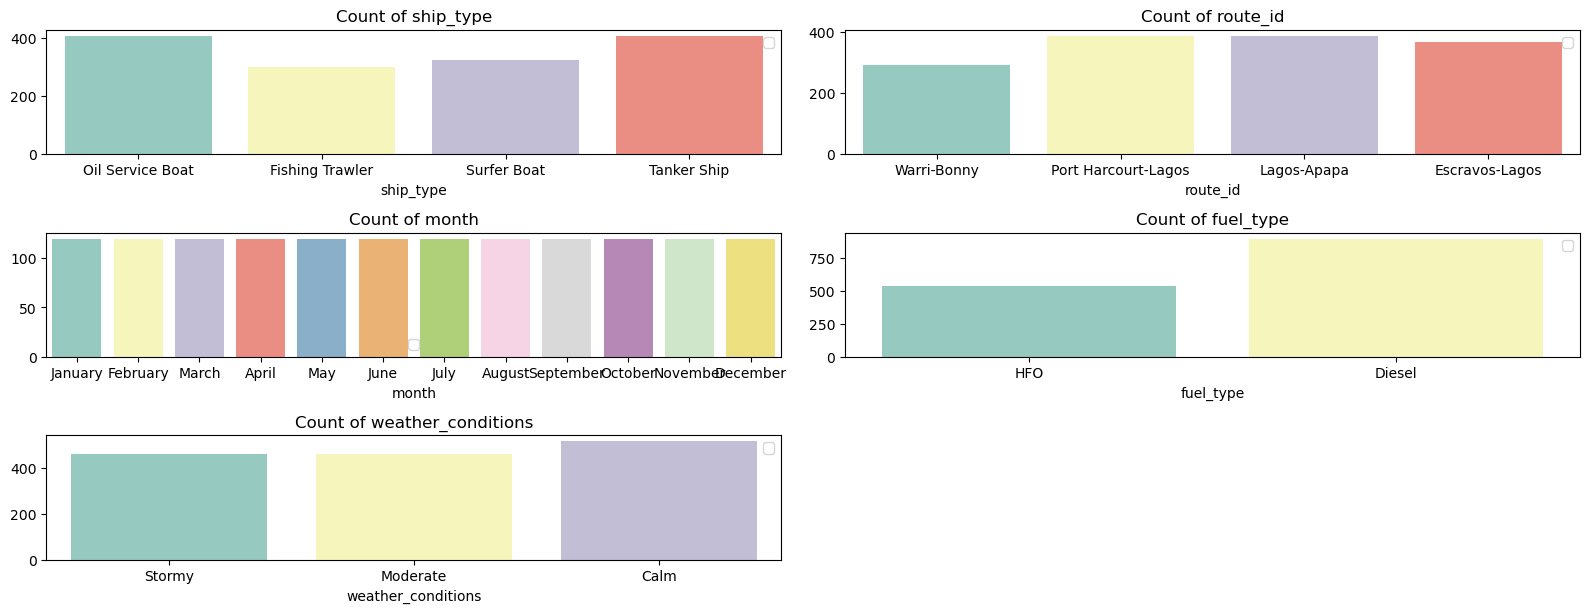

In [44]:
plt.figure(figsize=(16,20))
for i,col in enumerate(categoric_columns):
    i+=1
    plt.subplot(10,2,i)
    sns.countplot(x=df[col],palette="Set3")
    plt.legend()
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel(f"")
plt.tight_layout()
plt.show()

In [46]:
df.isnull().sum()


ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64

In [48]:
for col in categoric_columns:
    print(f"No of Unique Values in {col}:{df[col].nunique()}")

No of Unique Values in ship_type:4
No of Unique Values in route_id:4
No of Unique Values in month:12
No of Unique Values in fuel_type:2
No of Unique Values in weather_conditions:3


# Data Preprocessing

In [50]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
for col in categoric_columns:
    df[col]=label.fit_transform(df[col])

In [52]:
df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,1,3,4,132.26,1,3779.77,10625.76,2,92.14
1,NG001,1,2,3,128.52,1,4461.44,12779.73,1,92.98
2,NG001,1,2,7,67.30,1,1867.73,5353.01,0,87.61
3,NG001,1,2,0,71.68,0,2393.51,6506.52,2,87.42
4,NG001,1,1,8,134.32,1,4267.19,11617.03,0,85.61


In [54]:
dff=df[['ship_type','route_id','month','distance','fuel_type','fuel_consumption','CO2_emissions','weather_conditions','engine_efficiency']]

In [56]:
from sklearn.model_selection import train_test_split
x=dff.drop(columns=['fuel_consumption'])
y=dff['fuel_consumption']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,y_train.shape, x_test.shape,y_test.shape)

(1152, 8) (1152,) (288, 8) (288,)


In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train[numeric_columns]=scaler.fit_transform(x_train[numeric_columns])
x_test[numeric_columns]=scaler.transform(x_test[numeric_columns])

# Evaluation Metrics

In [64]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
def evaluation_metrics(model,y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=mse ** 0.5
    print(f"ML model :{model}")
    print("Mean Absolute Error:",mae)
    print("Mean Squared Error:",mse)
    print("Root Mean Squared Error:",rmse)
    print("*"*300)

# Ml Model

In [66]:
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
lr=LinearRegression()
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)
evaluation_metrics("Linear Regression",y_test,lr_pred)

ML model :Linear Regression
Mean Absolute Error: 219.07753855419452
Mean Squared Error: 120056.92574263859
Root Mean Squared Error: 346.49231700376646
************************************************************************************************************************************************************************************************************************************************************************************************************


In [68]:
rf=RandomForestRegressor(n_estimators=500)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
evaluation_metrics("Random Forest",y_test,rf_pred)

ML model :Random Forest
Mean Absolute Error: 225.29639062499965
Mean Squared Error: 147872.23631670058
Root Mean Squared Error: 384.5415924405325
************************************************************************************************************************************************************************************************************************************************************************************************************
